## Прогноз цен на авиабилеты

Авиакомпания — это компания, предоставляющая услуги воздушных перевозок пассажиров и грузов. Авиакомпании используют самолеты для предоставления этих услуг и могут заключать партнерские соглашения или альянсы с другими авиакомпаниями в рамках соглашений о код-шеринге, согласно которым они обе предлагают и выполняют один и тот же рейс. Как правило, авиакомпании признаются на основании сертификата или лицензии на осуществление воздушных перевозок, выданной государственным авиационным органом. Авиакомпании могут быть регулярными или чартерными операторами.

Авиакомпании устанавливают цены на свои услуги, стремясь максимизировать прибыль. Ценообразование авиабилетов с годами стало значительно сложнее и в настоящее время в значительной степени определяется компьютеризированными системами управления доходностью.

Цена авиабилета зависит от ряда факторов, таких как продолжительность полета, количество дней до вылета, время прибытия и отправления и т. д. Авиакомпании могут снижать стоимость в моменты, когда им необходимо нарастить спрос, и в моменты, когда билеты менее доступны. Они также могут максимизировать затраты. Цена может зависеть от различных факторов. Каждый фактор имеет свои собственные правила и алгоритмы для установления соответствующей цены. Последние достижения в области искусственного интеллекта (ИИ) и машинного обучения (МО) позволяют выводить такие правила и моделировать изменение цены.

### Импорт необходимых библиотек

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

### Загрузка данных

In [4]:
df = pd.read_csv("Clean_Dataset.csv", index_col=0)

In [3]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Описание набора данных

* **Airline** (Авиакомпания): Название авиакомпании хранится в столбце «Авиакомпания». Это категория, включающая 6 различных авиакомпаний.
* **Flight** (Рейс): Flight хранит информацию о коде рейса самолета. Это категориальный признак.
* **Source City** (Город-источник): Город, из которого вылетает самолет. Это категория, включающая 6 уникальных городов.
* **Departure Time** (Время отправления): это производная категориальная характеристика, полученная путем группировки временных периодов в интервалы. Она хранит информацию о времени отправления и имеет 6 уникальных временных меток.
* **Stops** (Остановки):Категориальный признак с тремя различными значениями, хранящий количество остановок между городами отправления и назначения.
* **Arrival Time** (Время прибытия): это производная категориальная характеристика, созданная путем группировки временных интервалов в интервалы. Она имеет шесть различных временных меток и содержит информацию о времени прибытия.
* **Destination City** (Город назначения): Город, где приземлится самолет. Это категория, включающая 6 уникальных городов.
* **Class** (Класс): Категориальный признак, содержащий информацию о классе места; имеет два различных значения: Бизнес и Эконом.
* **Duration** (Продолжительность): Непрерывный параметр, отображающий общее время, необходимое для поездки между городами в часах.
* **Days Left** (Осталось дней): это производная характеристика, которая рассчитывается путем вычитания даты поездки из даты бронирования.
* **Price** (Цена): Целевая переменная хранит информацию о цене билета.
не билета.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


### Как видно все столбцы, кроме трёх имеют тип данных object

In [19]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [23]:
df.describe(include='O')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


## Разведочный анализ данных (EDA)

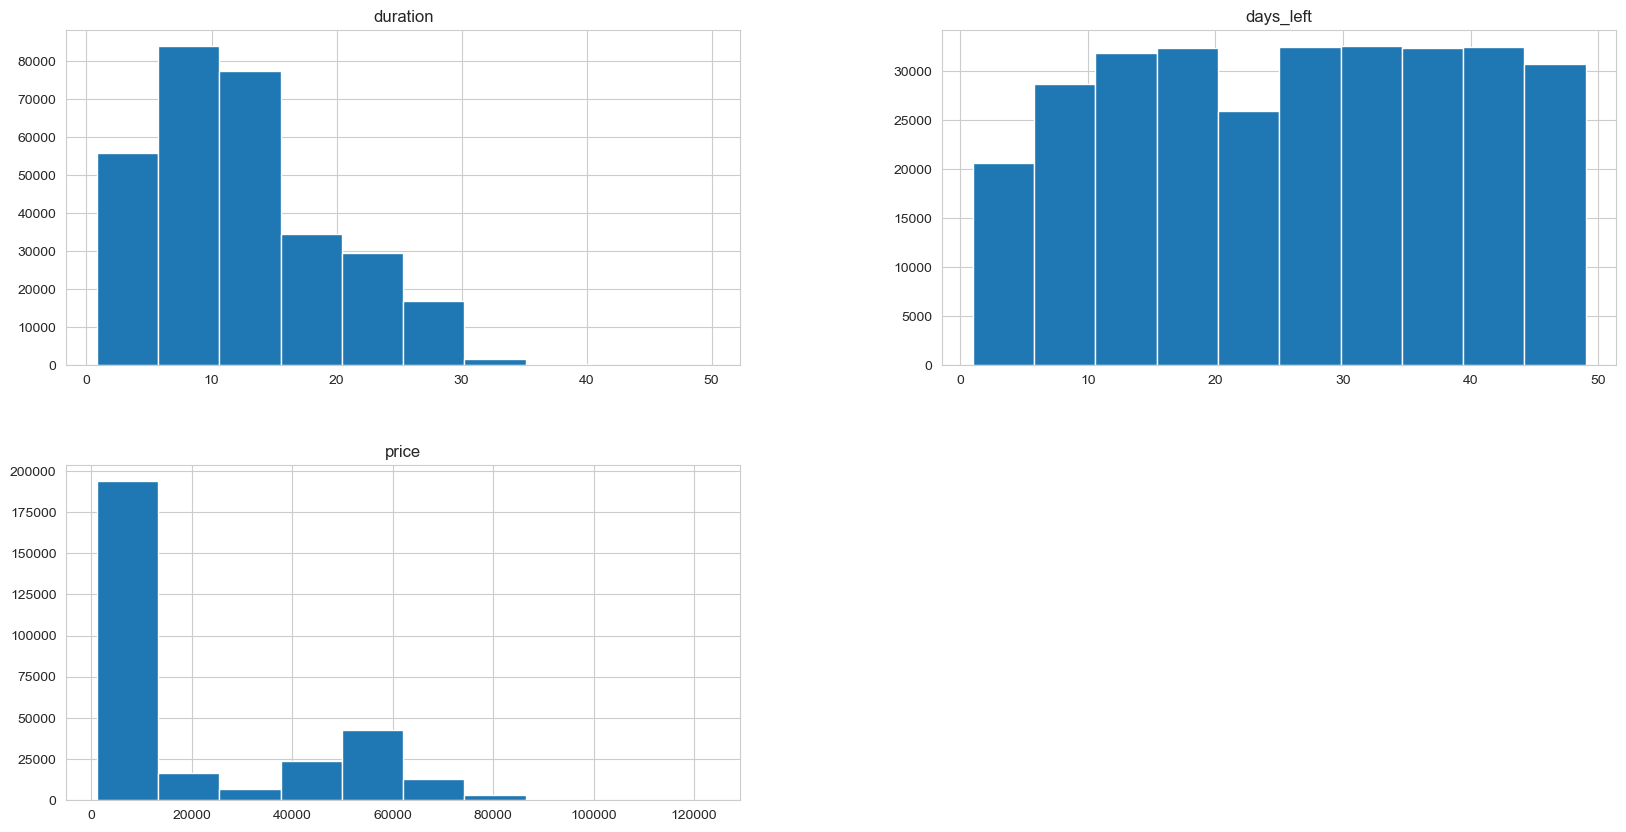

In [83]:
df.hist(figsize=(20,10));

### Вывод
#### Длительность полёта:
- Большинство рейсов короткие (до 10-15 часов)
- Есть "хвост" длительных перелетов (20-30 часов) - скорее всего сложные маршруты
#### Дней до вылета:
- Данные распределены почти равномерно
#### Цена билета:
- Видно что есть две "вспышки", скорее всего первая это эконом-класс, а вторая бизнес-класс

In [73]:
cat_features = [column for column in df.columns if df[column].dtype =="object"]

In [85]:
cat_features

['airline',
 'flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class']

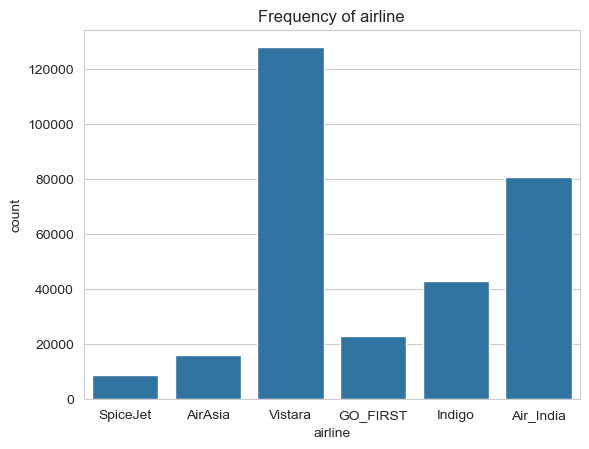

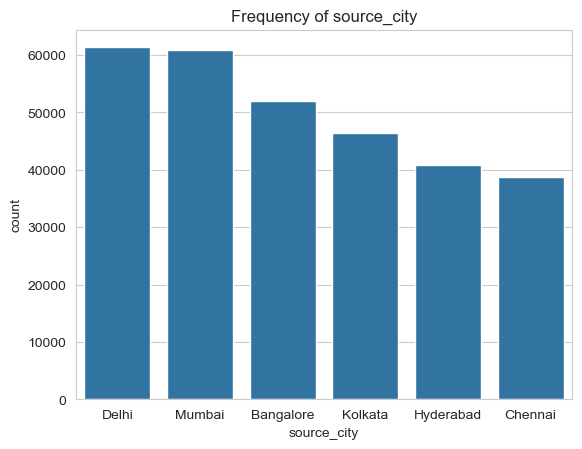

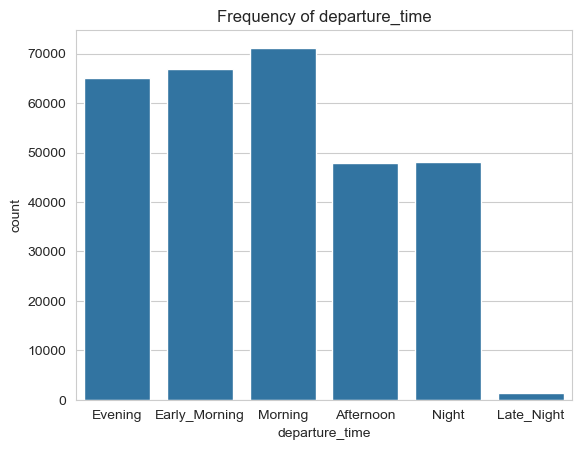

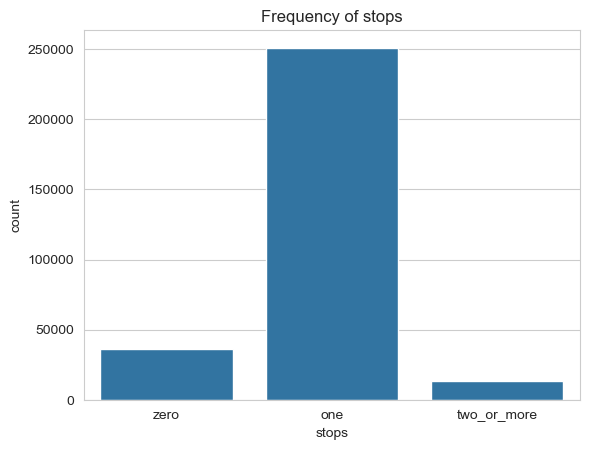

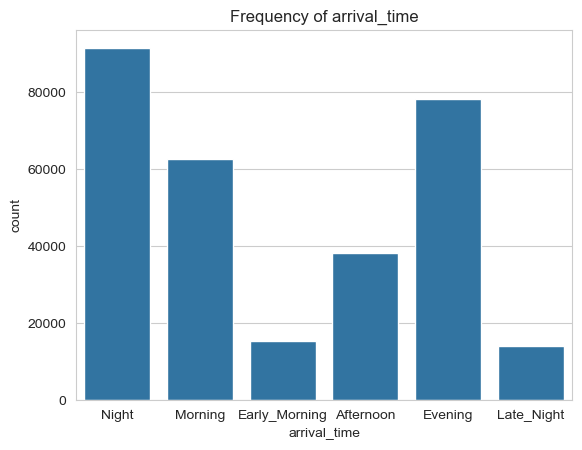

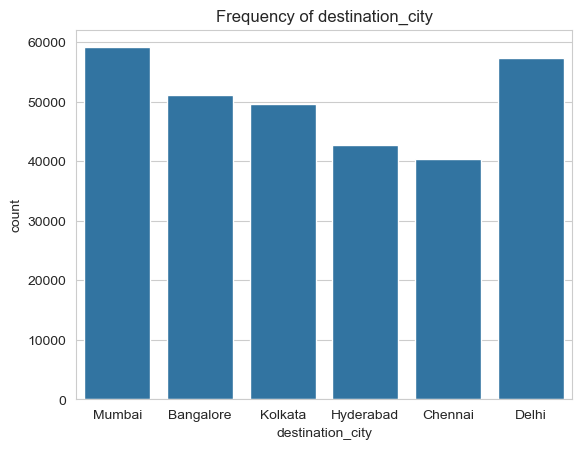

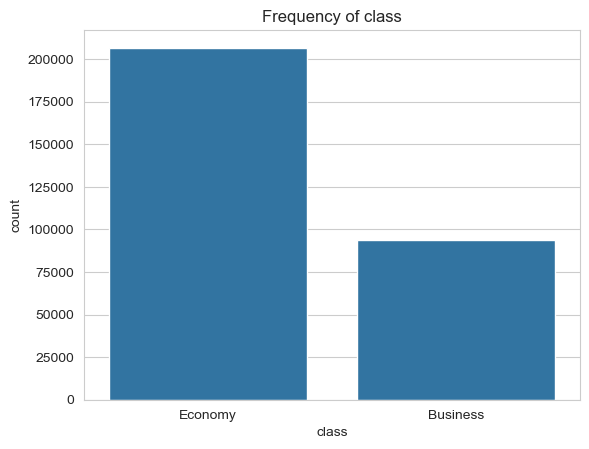

In [93]:
for column in cat_features:
    if column != 'flight':
        sns.countplot(x=df[column], data=df)
        plt.title("Frequency of " + column)
        plt.show()

### Краткий вывод по графикам:
#### Частота полетов в разных компаниях:
- Больше всего людей летает на самолётах компании Vistara и Air India, меньше всего на SpiceJet
#### Частота вылетов из городов:
- Больше всего людей вылетают из Delhi и Mumbai
#### Частота вылетов в определенное время:
- Больше всего людей вылетают вечером, рано утром и утром, а меньше всего вылетают днём и ночью
#### Частота время прибытия:
- прилетают больше всего ночью и вечером, так как часто всего вылетают вечером и утром
#### Частота прилтов в города:
- люди больше всего прилетают в Mumbai и Delhi
#### Частота полёта в классах:
- люди в основном летают в эконом-классе, меньшее кол-во в бизнес

#### Рассмотрел полёты некоторых самолётов

In [95]:
df[df['flight']=='SG-8709']

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
274,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,3,6060
398,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,4,5953
564,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,5,5953
739,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,6,5953
...,...,...,...,...,...,...,...,...,...,...,...
42049,SpiceJet,SG-8709,Delhi,Evening,one,Early_Morning,Chennai,Economy,13.08,43,4942
42053,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,26.42,43,4942
42228,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,26.83,44,4942
42381,SpiceJet,SG-8709,Delhi,Evening,one,Night,Chennai,Economy,27.00,45,4942


In [97]:
df[df['flight']=='SG-8709'].head(20)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
274,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,3,6060
398,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,4,5953
564,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,5,5953
739,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,6,5953
919,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,7,5953
1105,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,8,5953
1331,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,9,6060
1493,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,10,6270
1644,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,11,5953


#### Посмотрел количестово уникальных рейсов

In [104]:
df1=df.groupby(['flight','airline'],as_index=False).count()
df1.airline.value_counts()

airline
Indigo       704
Air_India    218
GO_FIRST     205
SpiceJet     186
Vistara      133
AirAsia      115
Name: count, dtype: int64

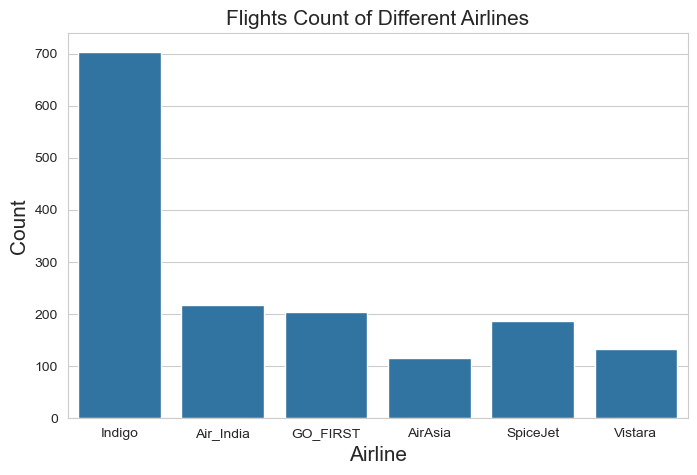

In [108]:
plt.figure(figsize=(8,5))
sns.countplot(x=df1['airline'])
plt.title('Flights Count of Different Airlines',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.show()

#### у Индиго больше всего уникальных маршрутов

In [112]:
df2=df.groupby(['flight','airline','class'],as_index=False).count()
df2['class'].value_counts()

class
Economy     1560
Business     295
Name: count, dtype: int64

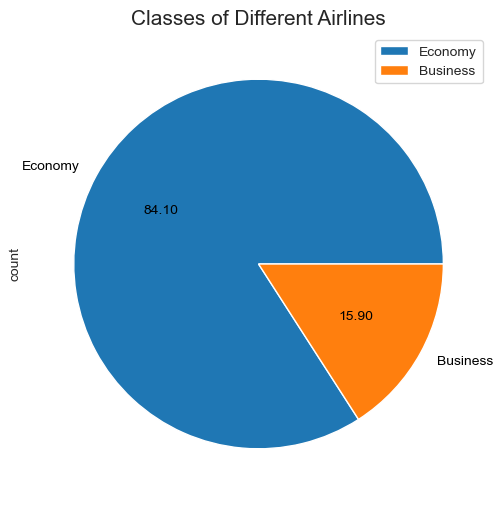

In [116]:
plt.figure(figsize=(8,6))
df2['class'].value_counts().plot(kind='pie',textprops={'color':'black'},autopct='%.2f')
plt.title('Classes of Different Airlines',fontsize=15)
plt.legend(['Economy','Business'])
plt.show()

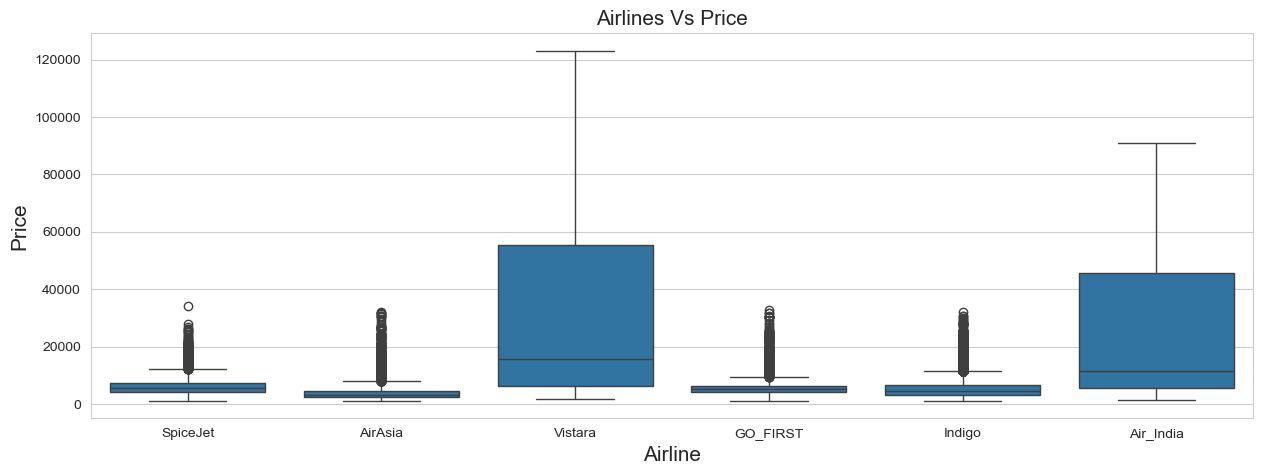

In [118]:
plt.figure(figsize=(15,5))
sns.boxplot(x=df['airline'],y=df['price'])
plt.title('Airlines Vs Price',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

#### Авиакомпании Vistara и Air India предлагают самые высокие цены по сравнению с другими. У SpiceJet, AirAsia, GO_First и Indigo цены примерно одинаковые.

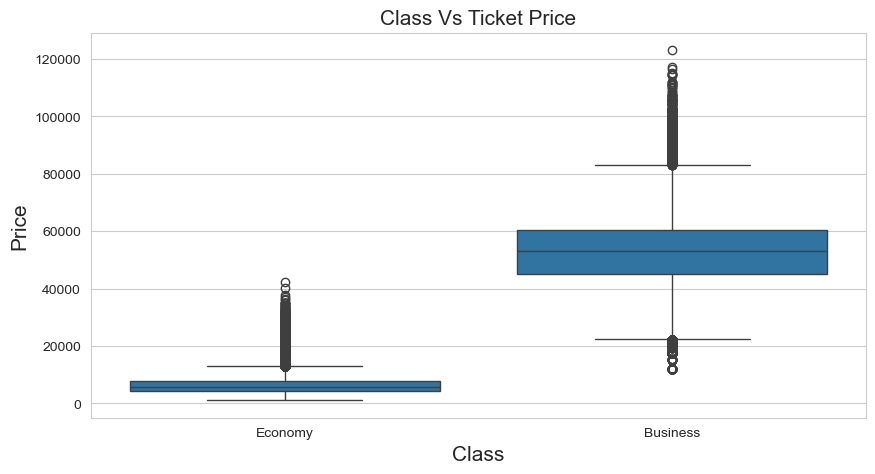

In [122]:
plt.figure(figsize=(10,5))
sns.boxplot(x='class',y='price',data=df)
plt.title('Class Vs Ticket Price',fontsize=15)
plt.xlabel('Class',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

#### Цена билета в бизнес-классе выше, чем в эконом-классе.

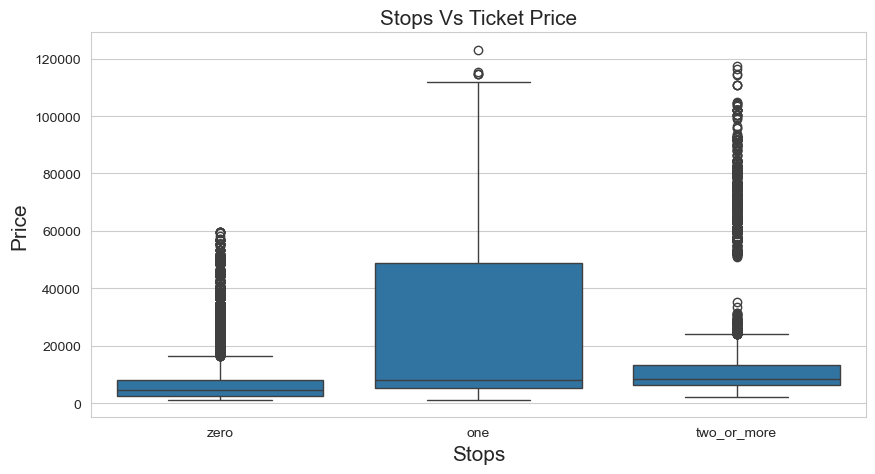

In [125]:
plt.figure(figsize=(10,5))
sns.boxplot(x='stops',y='price',data=df)
plt.title('Stops Vs Ticket Price',fontsize=15)
plt.xlabel('Stops',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

#### На рейсах с одной пересадкой действует максимальная цена билета.

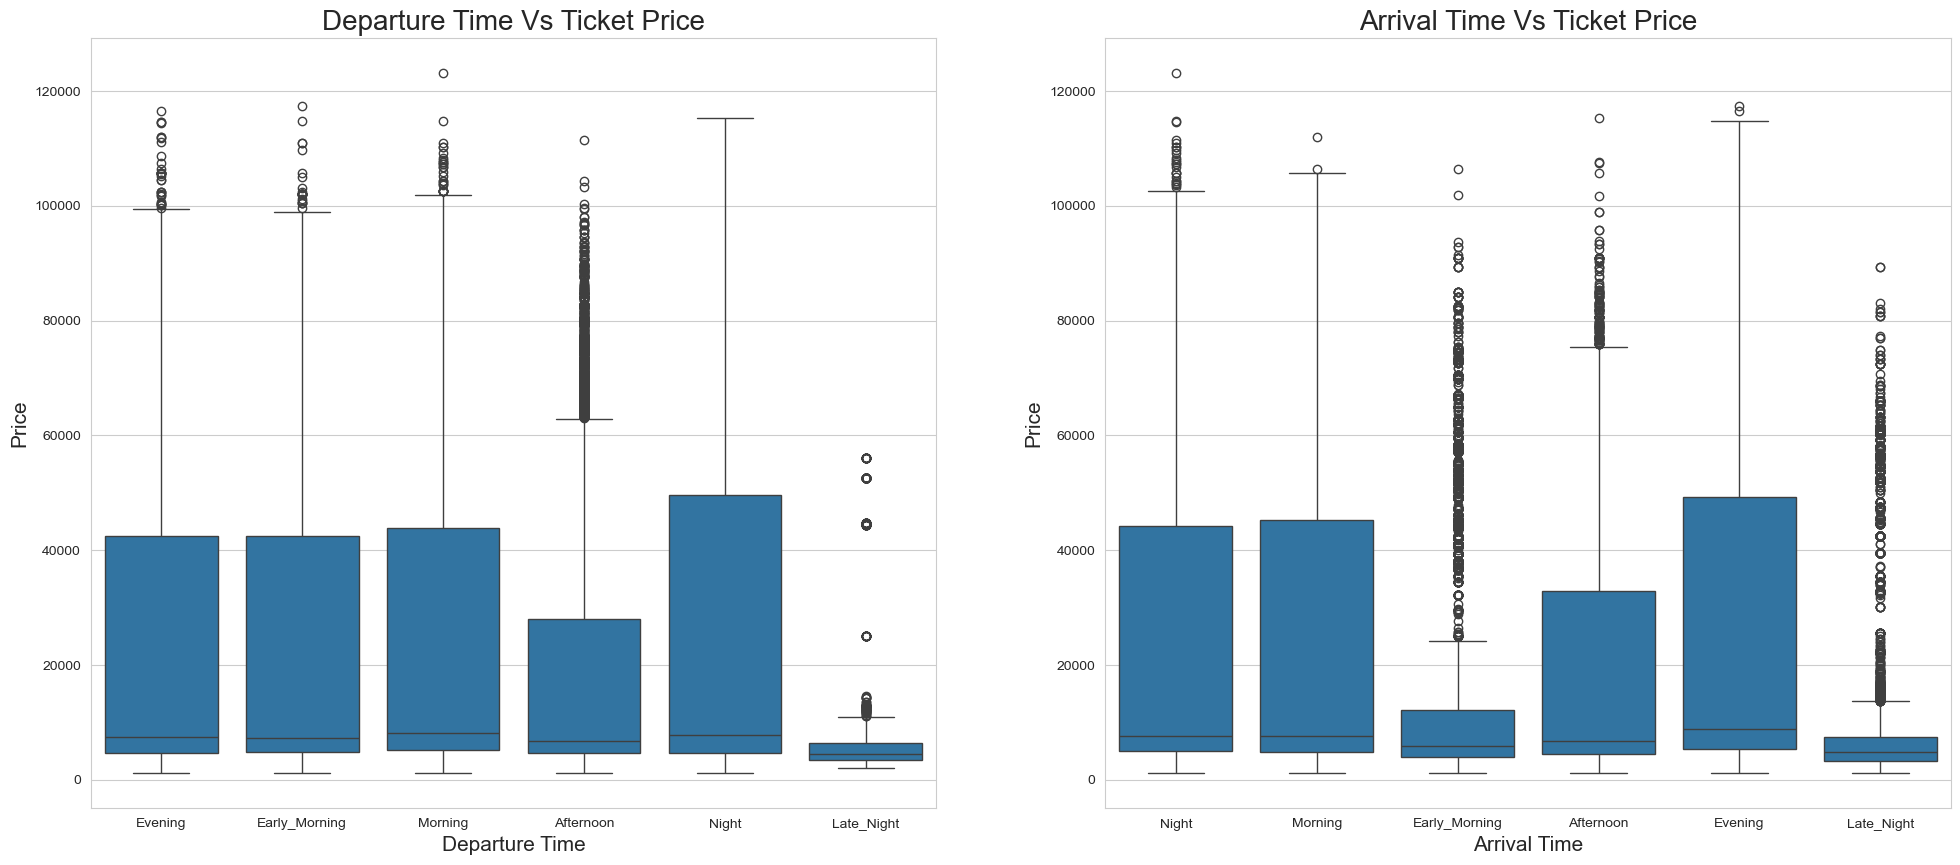

In [128]:
plt.figure(figsize=(24,10))
plt.subplot(1,2,1)
sns.boxplot(x='departure_time',y='price',data=df)
plt.title('Departure Time Vs Ticket Price',fontsize=20)
plt.xlabel('Departure Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.subplot(1,2,2)
sns.boxplot(x='arrival_time',y='price',data=df)
plt.title('Arrival Time Vs Ticket Price',fontsize=20)
plt.xlabel('Arrival Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

#### Стоимость билетов на рейсы, вылетающие ночью, выше.Стоимость билетов практически одинакова для рейсов с вылетом рано утром, утром и вечером.Низкие цены на билеты на рейсы с поздним ночным вылетом.

#### Стоимость билетов на рейсы с прибытием вечером выше.Стоимость билетов практически одинакова для рейсов, прибывающих утром и вечером.Стоимость билетов низкая на рейсы с поздним ночным временем прибытия, совпадающим со временем отправления.

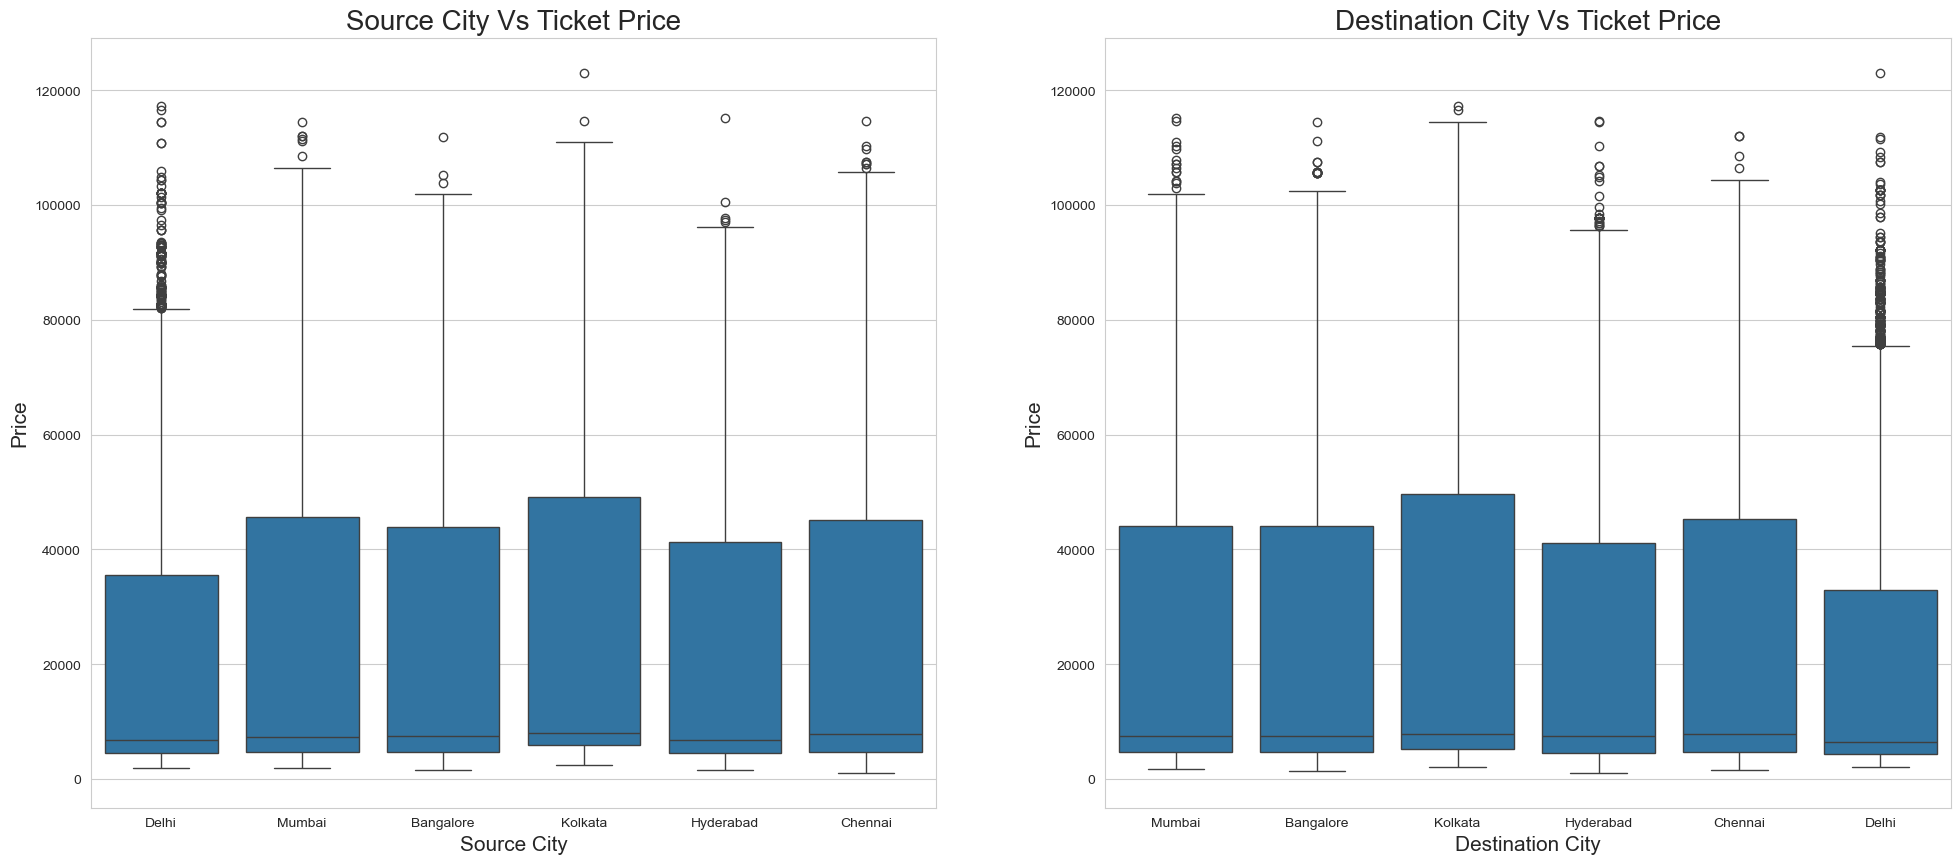

In [134]:
plt.figure(figsize=(24,10))
plt.subplot(1,2,1)
sns.boxplot(x='source_city',y='price',data=df)
plt.title('Source City Vs Ticket Price',fontsize=20)
plt.xlabel('Source City',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.subplot(1,2,2)
sns.boxplot(x='destination_city',y='price',data=df)
plt.title('Destination City Vs Ticket Price',fontsize=20)
plt.xlabel('Destination City',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

#### Цена билетов выше на рейсы, вылетающие из Калькутты.Стоимость билетов практически одинакова для рейсов из таких городов, как Мумбаи и Ченнаи, Хайдарабад и Бангалор.Цены на билеты на рейсы из Дели низкие.

#### Стоимость билетов выше на рейсы, пункты назначения которых — Калькутта и Ченнай.Стоимость билетов на рейсы в такие города, как Мумбай и Бангалор, практически одинакова.Цены на билеты на рейсы с городом назначения, таким как Дели, низкие.

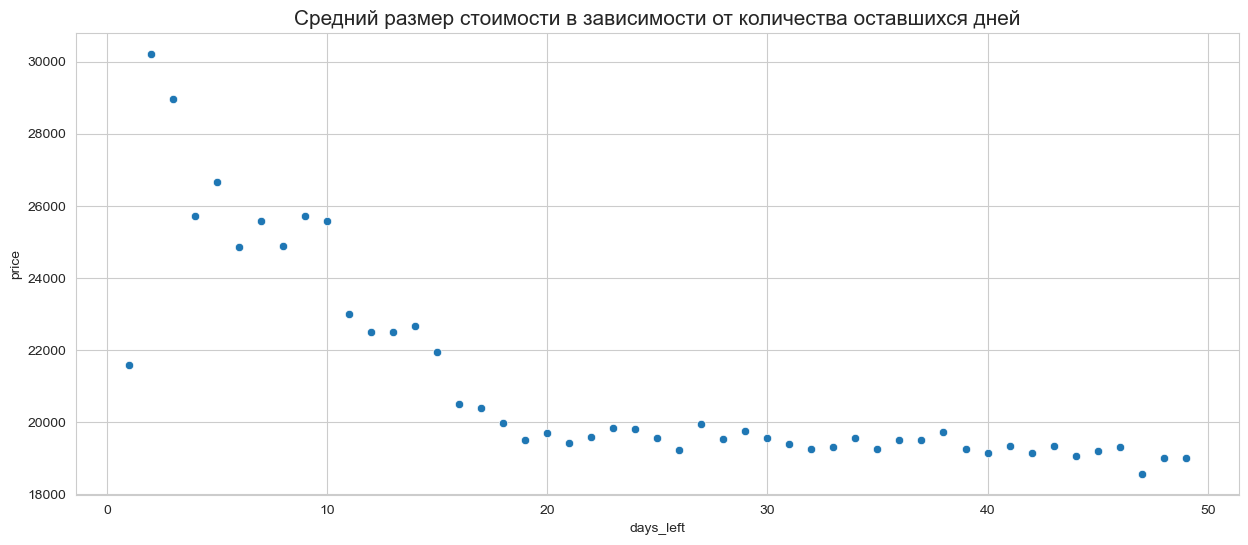

In [138]:
df_temp = df.groupby(['days_left'])['price'].mean().reset_index()

plt.figure(figsize=(15,6))
ax = sns.scatterplot(x="days_left", y="price", data=df_temp).set_title("Средний размер стоимости в зависимости от количества оставшихся дней",fontsize=15)

## Предобработка

### Удаляю столбец flight так как в нем много уникальных значений(1561) 

In [4]:
df = df.drop('flight', axis=1) 

In [6]:
mapping_stops = {'zero': 0, 'one': 1, 'two_or_more': 2}
mapping_class = {'Economy': 0, 'Business': 1}

In [7]:
df['stops'] = df['stops'].map(mapping_stops)
df['class'] = df['class'].map(mapping_class)

In [8]:
le = LabelEncoder()
cat_cols = ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Данные после кодирования:")
print(df.head())

Данные после кодирования:
   airline  source_city  departure_time  stops  arrival_time  \
0        4            2               2      0             5   
1        4            2               1      0             4   
2        0            2               1      0             1   
3        5            2               4      0             0   
4        5            2               4      0             4   

   destination_city  class  duration  days_left  price  
0                 5      0      2.17          1   5953  
1                 5      0      2.33          1   5953  
2                 5      0      2.17          1   5956  
3                 5      0      2.25          1   5955  
4                 5      0      2.33          1   5955  


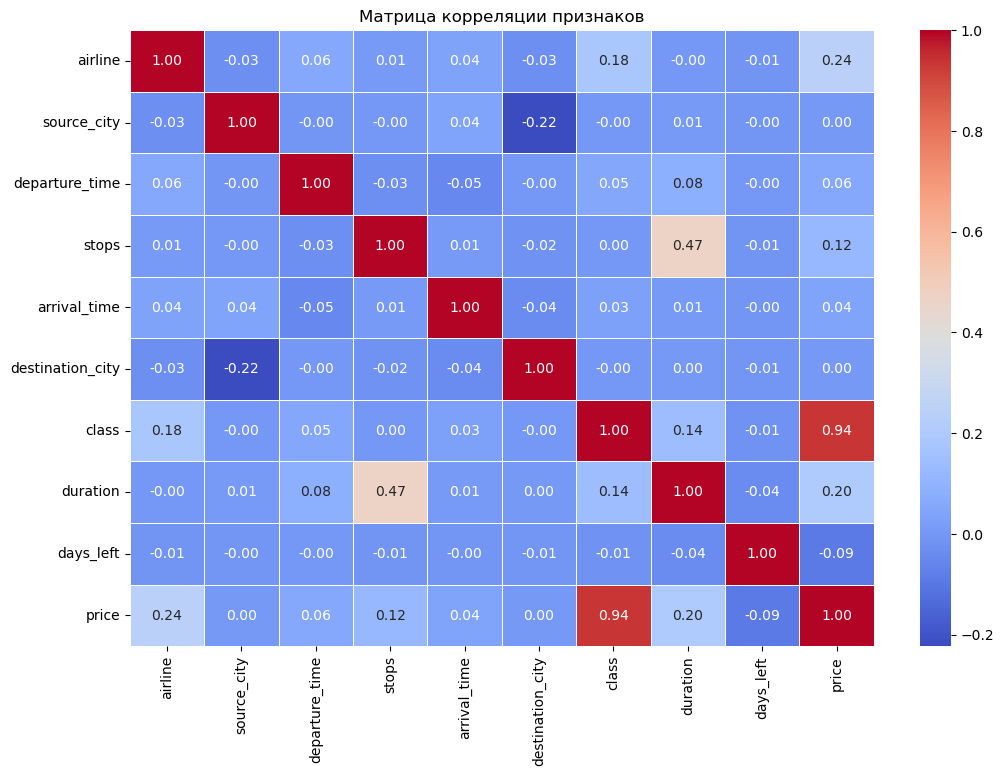

In [9]:
plt.figure(figsize=(12, 8))
# Вычисляем корреляцию
corr_matrix = df.corr()

# Строим тепловую карту
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матрица корреляции признаков')
plt.show()


### Есть зависимость, чем длинее продолжительность, тем больше остановок. Также видно что цена сильно зависит от класса.

## Обучение моделей

In [10]:
X = df.drop('price', axis=1)
y = df['price']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

### Тут нахожу точность и среднею абсолютных ошибок


In [18]:
print("\nРезультаты:")
print(f"{'Модель':<20}  {'R2 Score':<10}  {'MAE (Mean Abs Error)':<20}")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name:<20}  {r2:.4f}      {mae:.2f}")


Результаты:
Модель                R2 Score    MAE (Mean Abs Error)
Linear Regression     0.9063      4527.15
Decision Tree         0.9756      1175.64
Random Forest         0.9849      1091.58


### Анализ метрик:
1. R Score:
- Random Forest (0.9849): Это очень высокий результат.Это означает, что зависимости в данных очень четкие
- Linear Regression (0.9063): Результат неплохой, но заметно хуже, чем у деревьев
2. MAE:
- Linear Regression (4527.15): В среднем модель ошибается на 4500. Для дешевых билетов (которые стоят 5000–6000) это катастрофическая ошибка 
- Random Forest (1091.58): Ошибка снизилась более чем в 4 раза, ошибиться на 1000 — это вполне приемлемо для прогноза авиабилетов

### Визуализация

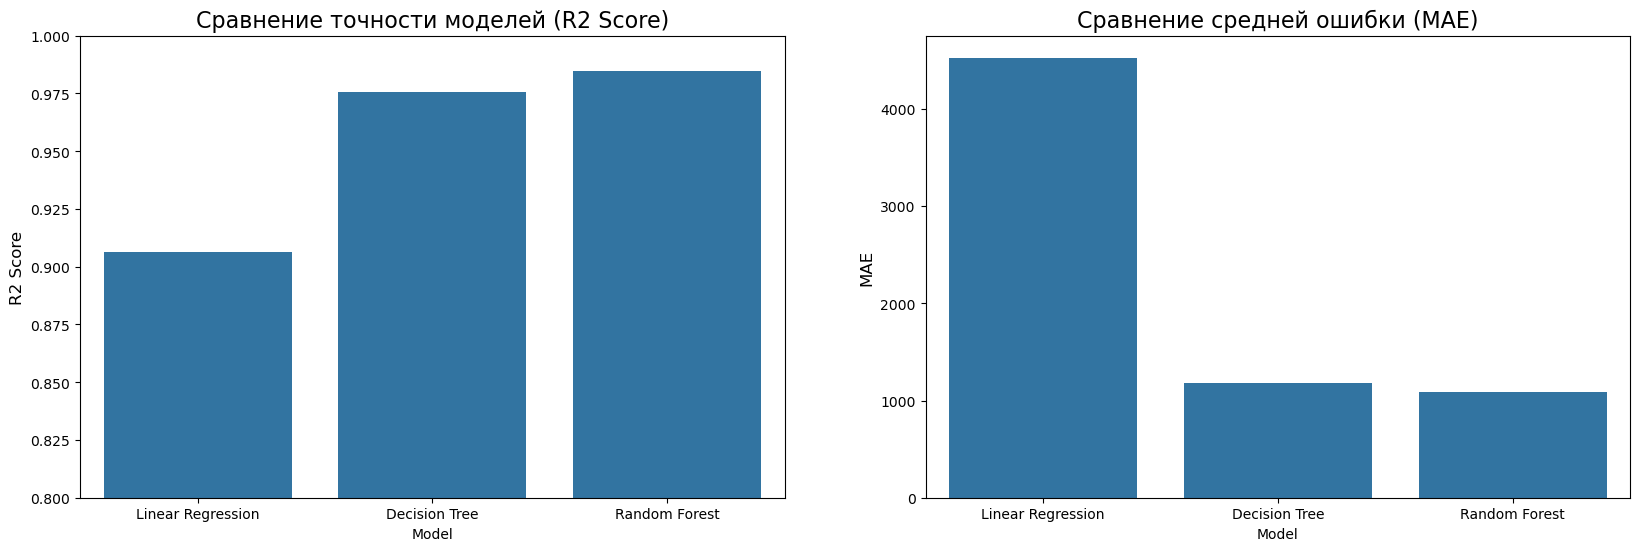

In [16]:
results_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [0.9063, 0.9756, 0.9849],
    'MAE': [4527.15, 1175.64, 1091.58]
}

df_res = pd.DataFrame(results_data)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(x='Model', y='R2 Score', data=df_res, ax=axes[0])
axes[0].set_title('Сравнение точности моделей (R2 Score)', fontsize=16)
axes[0].set_ylabel('R2 Score', fontsize=12)
axes[0].set_ylim(0.8, 1.0) 

sns.barplot(x='Model', y='MAE', data=df_res, ax=axes[1])
axes[1].set_title('Сравнение средней ошибки (MAE)', fontsize=16)
axes[1].set_ylabel('MAE', fontsize=12)
plt.show()

### Вывод:

1.Закодировал данные

2.Обучил 3 модели

3.Самая лучшая модель: Random Forest 